In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

import seaborn as sns
import joblib


In [2]:
df = pd.read_csv(r"C:\Users\Varalakshmi\Desktop\new_new_project\datasets\Diabetes_dataset\diabetes_dataset.csv")   
df.head()


,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0


In [3]:
df.shape


(100000, 16)

In [4]:
cols_to_drop = ["location", "year","race"]
df = df.drop(columns=cols_to_drop, errors="ignore")
df = df.drop(columns=[
    "race:AfricanAmerican",
    "race:Asian",
    "race:Caucasian",
    "race:Hispanic",
    "race:Other"
])

In [5]:
X = df.drop("diabetes", axis=1)
y = df["diabetes"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
# Remove race, location, year
#race_cols = [col for col in df.columns if "race" in col.lower()]
#df.drop(columns=race_cols + ["location", "year"], errors="ignore", inplace=True)

# Encode categorical columns
le_gender = LabelEncoder()
le_smoke = LabelEncoder()

# Fit on training data
X_train["gender"] = le_gender.fit_transform(X_train["gender"])
X_train["smoking_history"] = le_smoke.fit_transform(X_train["smoking_history"])

# Transform test data
X_test["gender"] = le_gender.transform(X_test["gender"])
X_test["smoking_history"] = le_smoke.transform(X_test["smoking_history"])


In [8]:
print(df.describe())
print(df.isnull().sum())


                 age  hypertension  heart_disease            bmi  \
count  100000.000000  100000.00000  100000.000000  100000.000000   
mean       41.885856       0.07485       0.039420      27.320767   
std        22.516840       0.26315       0.194593       6.636783   
min         0.080000       0.00000       0.000000      10.010000   
25%        24.000000       0.00000       0.000000      23.630000   
50%        43.000000       0.00000       0.000000      27.320000   
75%        60.000000       0.00000       0.000000      29.580000   
max        80.000000       1.00000       1.000000      95.690000   

         hbA1c_level  blood_glucose_level       diabetes  
count  100000.000000        100000.000000  100000.000000  
mean        5.527507           138.058060       0.085000  
std         1.070672            40.708136       0.278883  
min         3.500000            80.000000       0.000000  
25%         4.800000           100.000000       0.000000  
50%         5.800000           14

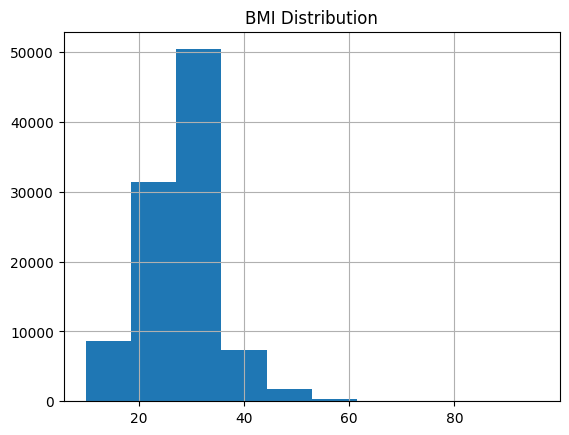

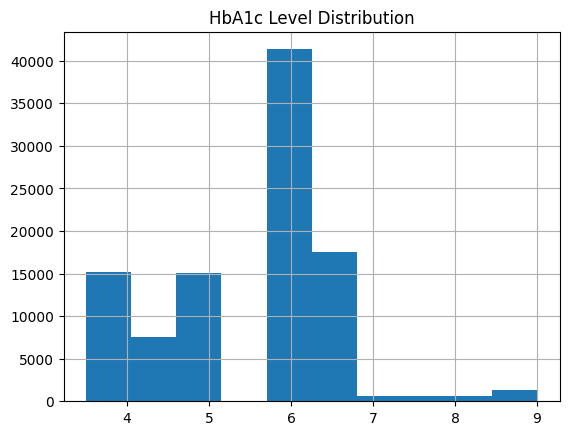

In [9]:
plt.figure()
df["bmi"].hist()
plt.title("BMI Distribution")
plt.show()

plt.figure()
df["hbA1c_level"].hist()
plt.title("HbA1c Level Distribution")
plt.show()


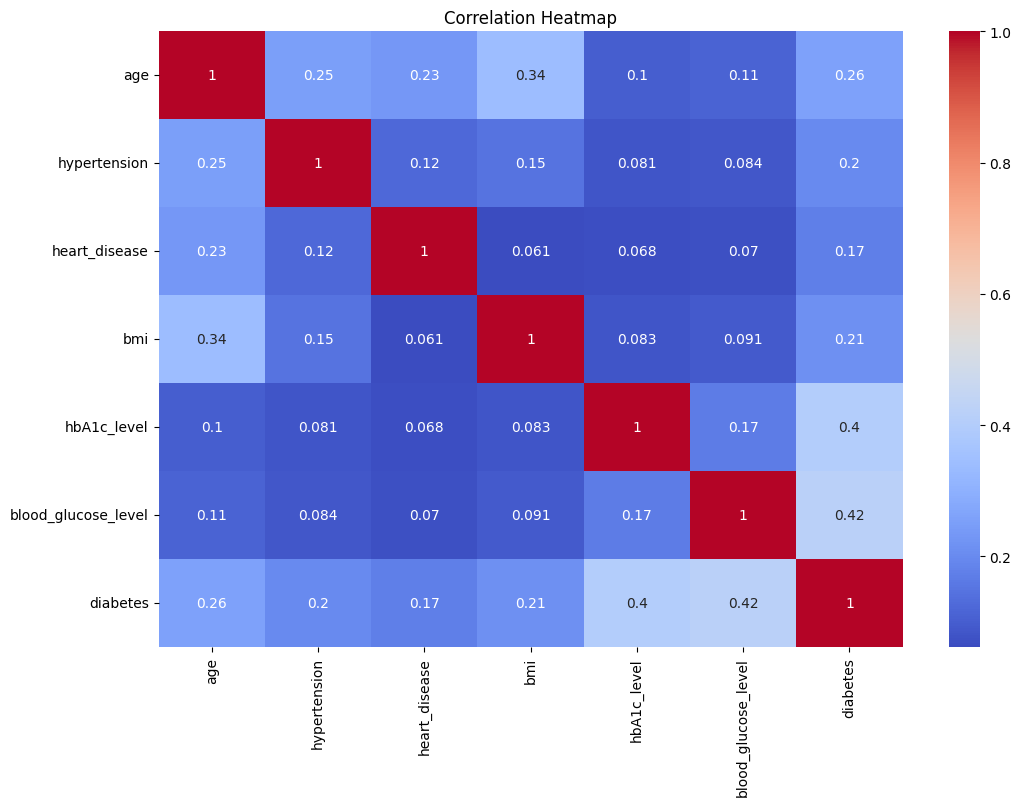

In [10]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [11]:
#X = df.drop("diabetes", axis=1)
##y = df["diabetes"]


#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)


In [12]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

In [13]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
import numpy as np
neg = np.sum(y_train == 0)
pos = np.sum(y_train == 1)
scale_weight = neg / pos

models = {
    "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=42),
    
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ),
    
    "SVM": SVC(
        class_weight="balanced",
          # Needed for predict_proba
        random_state=42
    ),
    
    "XGBoost": XGBClassifier(
        scale_pos_weight=scale_weight,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    )
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(name, "Accuracy:", accuracy_score(y_test, y_pred))


Random Forest Accuracy: 0.9701
Logistic Regression Accuracy: 0.8873
SVM Accuracy: 0.87495


C:\Users\Varalakshmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [10:43:26] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost Accuracy: 0.92055


In [14]:
from sklearn.metrics import accuracy_score, classification_report

for name, model in models.items():
    
    print(f"\n========== {name} ==========")
    
    # Train model
    model.fit(X_train, y_train)
    
    # Training accuracy
    y_train_pred = model.predict(X_train)
    train_acc = accuracy_score(y_train, y_train_pred)
    print("Training Accuracy:", round(train_acc, 4))
    
    # Testing accuracy
    y_test_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, y_test_pred)
    print("Testing Accuracy:", round(test_acc, 4))
    
    # Classification report (Test Data)
    print("\nClassification Report (Test Data):")
    print(classification_report(y_test, y_test_pred))


========== Random Forest ==========
Training Accuracy: 0.9991
Testing Accuracy: 0.9701

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18300
           1       0.95      0.69      0.80      1700

    accuracy                           0.97     20000
   macro avg       0.96      0.84      0.89     20000
weighted avg       0.97      0.97      0.97     20000


========== Logistic Regression ==========
Training Accuracy: 0.8864
Testing Accuracy: 0.8873

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.99      0.89      0.94     18300
           1       0.42      0.87      0.57      1700

    accuracy                           0.89     20000
   macro avg       0.70      0.88      0.75     20000
weighted avg       0.94      0.89      0.90     20000


========== SVM ==========
Training Accuracy: 0.8764
Testing Accuracy: 0.875

Classification

C:\Users\Varalakshmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [11:13:22] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Training Accuracy: 0.9344
Testing Accuracy: 0.9205

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.99      0.92      0.96     18300
           1       0.52      0.89      0.65      1700

    accuracy                           0.92     20000
   macro avg       0.75      0.90      0.80     20000
weighted avg       0.95      0.92      0.93     20000



In [15]:
# Calculate imbalance ratio
neg = np.sum(y_train == 0)
pos = np.sum(y_train == 1)
scale_weight = (neg / pos)*0.5

# Create XGBoost model
xgb = XGBClassifier(
    scale_pos_weight=scale_weight,
    random_state=42,
    use_label_encoder=False,
    
    eval_metric='logloss'
)

# Train
xgb.fit(X_train, y_train)

# Predict probabilities
y_prob = xgb.predict_proba(X_test)[:, 1]

# Apply threshold (you can tune this)
y_pred_new = (y_prob > 0.56).astype(int)

# Evaluation
print(classification_report(y_test, y_pred_new))

C:\Users\Varalakshmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [11:13:23] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


              precision    recall  f1-score   support

           0       0.98      0.97      0.98     18300
           1       0.72      0.79      0.75      1700

    accuracy                           0.96     20000
   macro avg       0.85      0.88      0.86     20000
weighted avg       0.96      0.96      0.96     20000



In [23]:
print(xgb.feature_names_in_)

['gender' 'age' 'hypertension' 'heart_disease' 'smoking_history' 'bmi'
 'hbA1c_level' 'blood_glucose_level']


In [24]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred_new))
print(classification_report(y_test, y_pred_new))

[[17766   534]
 [  353  1347]]
              precision    recall  f1-score   support

           0       0.98      0.97      0.98     18300
           1       0.72      0.79      0.75      1700

    accuracy                           0.96     20000
   macro avg       0.85      0.88      0.86     20000
weighted avg       0.96      0.96      0.96     20000



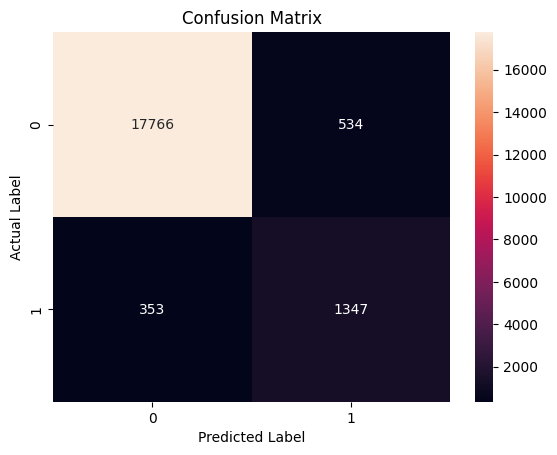

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred_new)

# Plot
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.show()

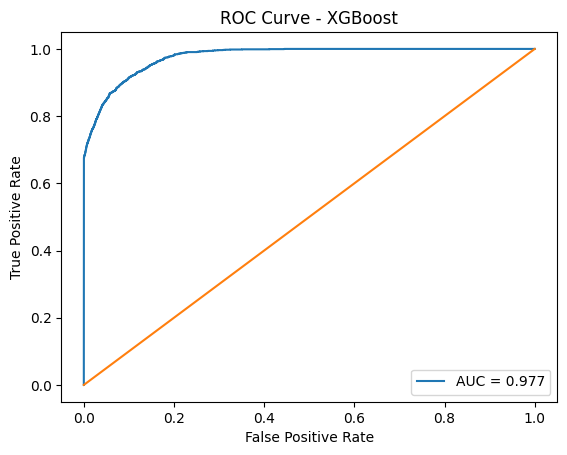

In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
y_prob = xgb.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1])  # Diagonal line (random model)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend(loc="lower right")

plt.show()


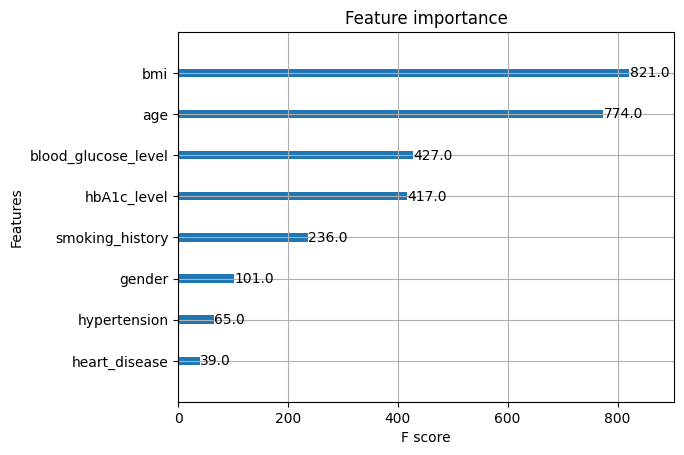

In [27]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

# Assuming your model is named 'xgb'
plot_importance(xgb, importance_type='weight')  # default is 'weight'
plt.show()

In [29]:
import joblib

joblib.dump(xgb, "model/diabetes_model.pkl")
print("Model Saved in model folder!")


Model Saved in model folder!
